# Data preprocessing


In [9]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy.signal import hilbert, welch, butter, filtfilt, spectrogram
from scipy.ndimage import uniform_filter1d
import segyio
import os, time

# ── Plotting defaults ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'      : 300,
    'axes.titlesize'  : 12,
    'axes.labelsize'  : 10,
    'xtick.labelsize' : 8,
    'ytick.labelsize' : 8,
    'font.family'     : 'DejaVu Sans',
})
CMAP_SEIS  = 'seismic'
CMAP_AMP   = 'plasma'
CMAP_PHASE = 'hsv'
CMAP_FREQ  = 'jet'

In [10]:
def load_seismic_data(filepath):
    with segyio.open(filepath, "r", ignore_geometry=True) as f:
        f.mmap()

        # Try to detect geometry
        has_geometry = (
            f.ilines is not None and
            f.xlines is not None and
            f.offsets is not None
        )

        if has_geometry:
            print("✅ Structured 3D detected")
            data = segyio.tools.cube(f)

            # Handle 3D or 4D
            if data.ndim == 4:  # prestack
                data = data[:, :, 0, :]
            elif data.ndim == 3:
                data = data[0, :, :]  # take one inline

        else:
            print("In this data we have no geometry → loading as 2D traces")
            n_traces = f.tracecount
            n_samples = len(f.samples)

            data = np.zeros((n_traces, n_samples), dtype=np.float32)

            for i in range(n_traces):
                data[i, :] = f.trace[i]

        return data.T  # (samples, traces)

filepath = "/home/ashraf/Desktop/100-Days-of-Python-for-Oil-Gas-Subsurface-Analytics-Well-log/notebooks/day-20-25_seismic_fault_mapping/seismic_output/converted.segy"  

seismic = load_seismic_data(filepath)

print("Shape:", seismic.shape)
print("Shape:", seismic.shape)
print("Samples:", seismic.shape[0])
print("Traces:", seismic.shape[1])




In this data we have no geometry → loading as 2D traces
Shape: (1500, 645)
Shape: (1500, 645)
Samples: 1500
Traces: 645


In [11]:
import segyio
t0=time.time()
with segyio.open("/home/ashraf/Desktop/100-Days-of-Python-for-Oil-Gas-Subsurface-Analytics-Well-log/notebooks/day-20-25_seismic_fault_mapping/seismic_output/converted.segy" , "r", ignore_geometry=True) as f:
    print("Traces:", f.tracecount)
    print("Samples per trace:", len(f.samples))
    print("Inline:", f.ilines)
    print("Crossline:", f.xlines)
    print("Offsets:", f.offsets)

    # DT
    dt_ms=segyio.tools.dt(f)/1000.0     # µs → ms
    print("The dt of the seismic data is:",dt_ms)

    print("Sample size of the data:",f.samples.size)
    data=segyio.tools.collect(f.trace[:]) # (n_traces, n_samples)
    data=data.T     # → (n_samples, n_traces)

    print(data)

Traces: 645
Samples per trace: 1500
Inline: None
Crossline: None
Offsets: None
The dt of the seismic data is: 2.0
Sample size of the data: 1500
[[5.8315540e-39 0.0000000e+00 0.0000000e+00 ... 0.0000000e+00
  0.0000000e+00 0.0000000e+00]
 [2.3509887e-38 0.0000000e+00 0.0000000e+00 ... 1.0165873e+01
  1.0174810e+01 1.0183750e+01]
 [4.2351647e-22 0.0000000e+00 0.0000000e+00 ... 2.0000000e+00
  0.0000000e+00 2.0000000e+00]
 ...
 [0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 1.0174786e+01
  1.0183725e+01 1.0192665e+01]
 [0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 0.0000000e+00
  2.0000000e+00 2.0000000e+00]
 [0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 1.3448775e+01
  1.3448797e+01 1.3448819e+01]]


[INFO] Shape: (645, 1500)
[INFO] dt: 2.00 ms


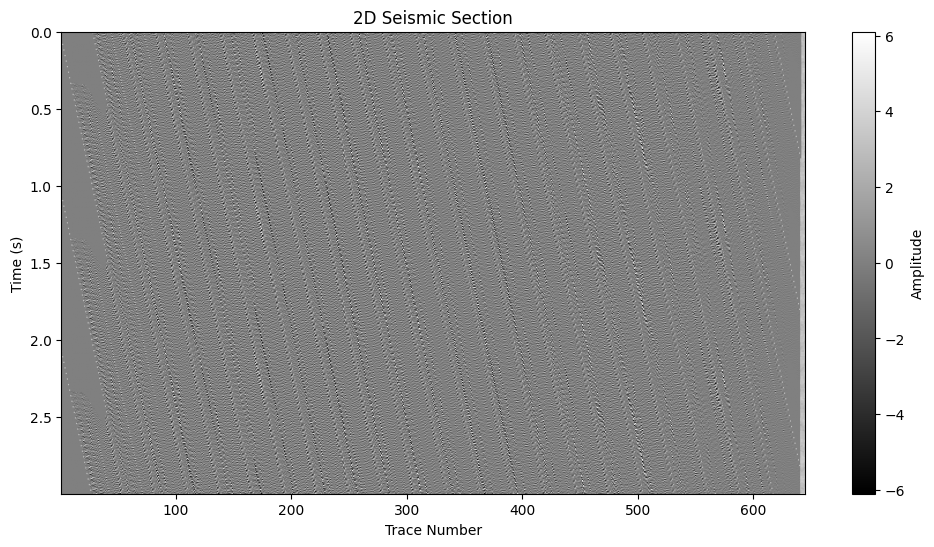

In [8]:
segy_path = "seismic_output/converted.segy"

seismic = read_segy_2d(segy_path)

plot_seismic(seismic)